# Percolation Finite-Size Scaling and Critical Exponents

Cluster labeling, order parameter and susceptibility measurements, and estimates of beta, gamma, and nu near the percolation threshold.

Computational physics coursework by Udayan Sharma. Original code comments and saved outputs are retained. See the repository README for execution notes.


Running L = 50 ...
Running L = 75 ...
Running L = 100 ...
Running L = 150 ...
Running L = 200 ...
Running L = 300 ...
Running L = 400 ...
Running L = 600 ...
Running L = 800 ...
Running L = 1000 ...

Averaged results
---------------------------------------------------------------
     L          <P>       SEM(P)          <chi>       SEM(chi)
---------------------------------------------------------------
    50     0.475923     0.016933      39.394516       2.787970
    75     0.443137     0.017311      72.323655       5.690422
   100     0.448000     0.016282     114.120747       9.146068
   150     0.442860     0.016023     238.352567      20.587962
   200     0.424925     0.016257     405.223791      33.850746
   300     0.406355     0.014712     876.610199      70.260460
   400     0.414249     0.015823    1320.930967     112.452744
   600     0.383320     0.013150    2722.114380     208.302392
   800     0.362517     0.012114    4722.827994     355.903059
  1000     0.351368     0

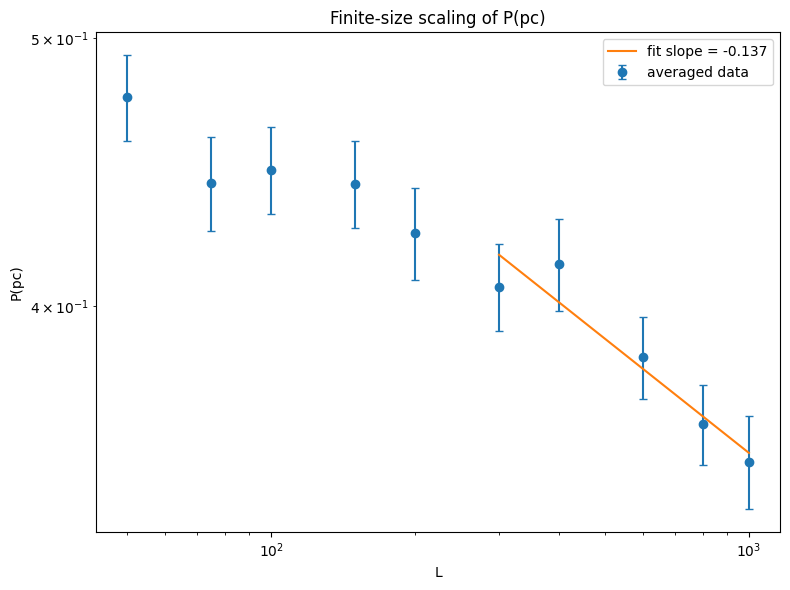

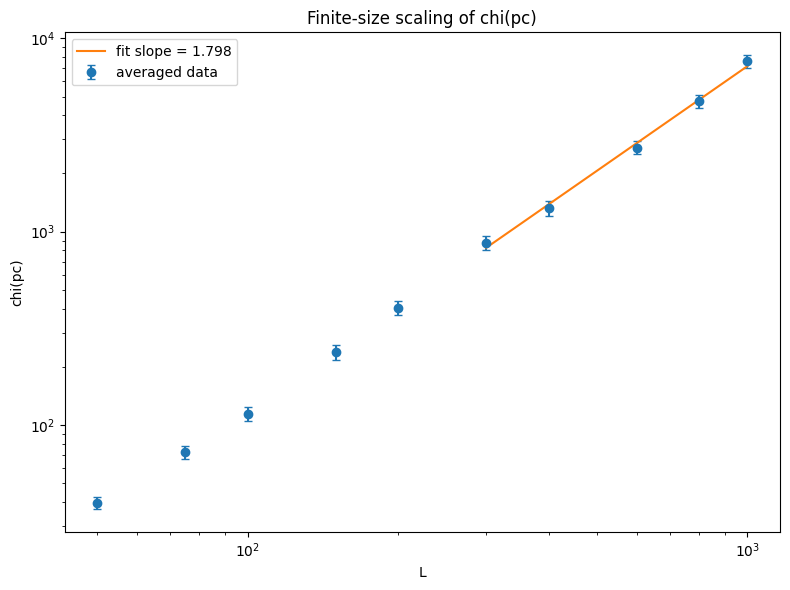

In [ ]:
# Lab 10 - Task 1

import numpy as np;
import random;
import matplotlib.pyplot as plt;


# Percolation generator
def generate(p, grid):
    L = grid.shape[0];
    grid.fill(0);
    labels = np.zeros(L * L, dtype = int);
    lbl = 0;

    for i in range(L):
        for j in range(L):
            if random.random() > p:
                continue;

            topIdx = grid[i, j - 1] if j > 0 else 0;
            leftIdx = grid[i - 1, j] if i > 0 else 0;

            while labels[topIdx] < 0:
                topIdx = -labels[topIdx];
            while labels[leftIdx] < 0:
                leftIdx = -labels[leftIdx];

            if topIdx == 0 and leftIdx == 0:
                lbl += 1;
                trueIdx = lbl;
            elif topIdx == 0:
                trueIdx = leftIdx;
            elif leftIdx == 0:
                trueIdx = topIdx;
            else:
                if topIdx != leftIdx:
                    idxLO = min(topIdx, leftIdx);
                    idxHI = max(topIdx, leftIdx);
                    trueIdx = idxLO;
                    labels[idxLO] += labels[idxHI];
                    labels[idxHI] = -idxLO;
                else:
                    trueIdx = leftIdx;

            grid[i, j] = trueIdx;
            labels[trueIdx] += 1;

    Noccupied = 0;
    sDist = {};

    for idx in range(1, lbl + 1):
        s = labels[idx];
        if s < 0:
            continue;
        Noccupied += s;
        if s not in sDist:
            sDist[s] = 1;
        else:
            sDist[s] += 1;

    sDist = sorted(sDist.items());   # list of (s, Ns)
    return Noccupied, sDist;


# Single-sample estimators of P and chi
def compute_P_chi(L, Noccupied, sDist):
    if Noccupied == 0 or len(sDist) == 0:
        return 0.0, 0.0;

    s_max = sDist[-1][0];
    # Percolation probability estimator: fraction of occupied sites belonging to the largest cluster
    P = s_max / Noccupied;
    chi = 0.0;   # Susceptibility estimator: mean finite-cluster size up to an overall factor

    for s, Ns in sDist[:-1]:   # exclude largest cluster
        chi += s * s * Ns;
    chi /= (L * L);

    return P, chi;


# Run many realizations for one lattice size
def run_size(L, p, Nsamples):
    grid = np.zeros((L, L), dtype = int);
    P_vals = np.zeros(Nsamples);
    chi_vals = np.zeros(Nsamples);

    for n in range(Nsamples):
        Noccupied, sDist = generate(p, grid);
        P_vals[n], chi_vals[n] = compute_P_chi(L, Noccupied, sDist);

    return {"L": L, "P_mean": np.mean(P_vals), "P_sem": np.std(P_vals, ddof = 1) / np.sqrt(Nsamples), "chi_mean": np.mean(chi_vals),
        "chi_sem": np.std(chi_vals, ddof = 1) / np.sqrt(Nsamples),};


# Log-log fit
def loglog_fit(x, y):
    lx = np.log(x);
    ly = np.log(y);
    slope, intercept = np.polyfit(lx, ly, 1);
    ly_fit = slope * lx + intercept;
    ss_res = np.sum((ly - ly_fit) ** 2);
    ss_tot = np.sum((ly - np.mean(ly)) ** 2);
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan;

    return slope, intercept, r2;


# Main
def main():
    # Parameters
    p = 0.593;
    L_values = np.array([50, 75, 100, 150, 200, 300, 400, 600, 800, 1000], dtype = int);
    Nsamples = 100;
    random.seed(12345);
    np.random.seed(12345);
    results = [];

    for L in L_values:
        print(f"Running L = {L} ...");
        results.append(run_size(L, p, Nsamples));

    # Convert to arrays
    L = np.array([r["L"] for r in results], dtype = float);
    P_mean = np.array([r["P_mean"] for r in results], dtype = float);
    P_sem = np.array([r["P_sem"] for r in results], dtype = float);
    chi_mean = np.array([r["chi_mean"] for r in results], dtype = float);
    chi_sem = np.array([r["chi_sem"] for r in results], dtype = float);

    # Fit only the largest half of the sizes to reduce small-L finite-size effects
    fit_start = len(L) // 2;
    L_fit = L[fit_start:];
    P_fit = P_mean[fit_start:];
    chi_fit = chi_mean[fit_start:];
    slope_P, intercept_P, r2_P = loglog_fit(L_fit, P_fit);
    slope_chi, intercept_chi, r2_chi = loglog_fit(L_fit, chi_fit);
    beta_over_nu = -slope_P
    gamma_over_nu = slope_chi


    print("\nAveraged results");
    print("---------------------------------------------------------------");
    print(f"{'L':>6} {'<P>':>12} {'SEM(P)':>12} {'<chi>':>14} {'SEM(chi)':>14}");
    print("---------------------------------------------------------------");
    for i in range(len(L)):
        print(f"{int(L[i]):6d} {P_mean[i]:12.6f} {P_sem[i]:12.6f} {chi_mean[i]:14.6f} {chi_sem[i]:14.6f}");
    print("\nLarge-L log-log fits");
    print("---------------------------------------------------------------");
    print(f"Fit range: L >= {int(L_fit[0])}");
    print(f"P(pc)   ~ L^m : m = {slope_P:.6f}   =>   beta/nu  = {beta_over_nu:.6f}");
    print(f"chi(pc) ~ L^m : m = {slope_chi:.6f}   =>   gamma/nu = {gamma_over_nu:.6f}");
    print(f"R^2 for P fit   = {r2_P:.6f}");
    print(f"R^2 for chi fit = {r2_chi:.6f}");

    # Save summary data
    #out = np.column_stack([L, P_mean, P_sem, chi_mean, chi_sem]);
    #np.savetxt("task1_results.csv", out, delimiter = ",", header = "L,P_mean,P_sem,chi_mean,chi_sem", comments = "");

    # Plot P(p_c)
    plt.figure(figsize = (8, 6))
    plt.errorbar(L, P_mean, yerr = P_sem, fmt = 'o', capsize = 3, label = 'averaged data');
    plt.plot(L_fit, np.exp(intercept_P) * L_fit**slope_P, label = f'fit slope = {slope_P:.3f}');
    plt.xscale('log');
    plt.yscale('log');
    plt.xlabel("L");
    plt.ylabel("P(pc)");
    plt.title("Finite-size scaling of P(pc)");
    plt.legend();
    plt.tight_layout();
    plt.savefig("task1_P_scaling.png", dpi = 200);

    # Plot chi(p_c)
    plt.figure(figsize = (8, 6));
    plt.errorbar(L, chi_mean, yerr = chi_sem, fmt = 'o', capsize = 3, label = 'averaged data');
    plt.plot(L_fit, np.exp(intercept_chi) * L_fit**slope_chi, label = f'fit slope = {slope_chi:.3f}');
    plt.xscale('log');
    plt.yscale('log');
    plt.xlabel("L");
    plt.ylabel("chi(pc)");
    plt.title("Finite-size scaling of chi(pc)");
    plt.legend();
    plt.tight_layout();
    plt.savefig("task1_chi_scaling.png", dpi = 200);

    plt.show();


if __name__ == "__main__":
    main();

# EOF


Running p = 0.570 ...
Running p = 0.575 ...
Running p = 0.580 ...
Running p = 0.583 ...
Running p = 0.587 ...
Running p = 0.590 ...
Running p = 0.594 ...
Running p = 0.597 ...
Running p = 0.600 ...
Running p = 0.605 ...
Running p = 0.610 ...
Running p = 0.620 ...

Averaged results
-----------------------------------------------------------------------
       p          <P>       SEM(P)          <chi>       SEM(chi)
-----------------------------------------------------------------------
   0.570     0.017282     0.000646     648.145349       9.547096
   0.575     0.025699     0.001013    1036.367699      15.756565
   0.580     0.045610     0.001957    1901.470931      55.786285
   0.583     0.067364     0.003178    2870.879683      78.741348
   0.587     0.127313     0.008296    5042.644349     214.646769
   0.590     0.229157     0.011821    6722.222659     454.703802
   0.594     0.434599     0.018278    6516.865192     887.318961
   0.597     0.598101     0.011059    2276.841506     

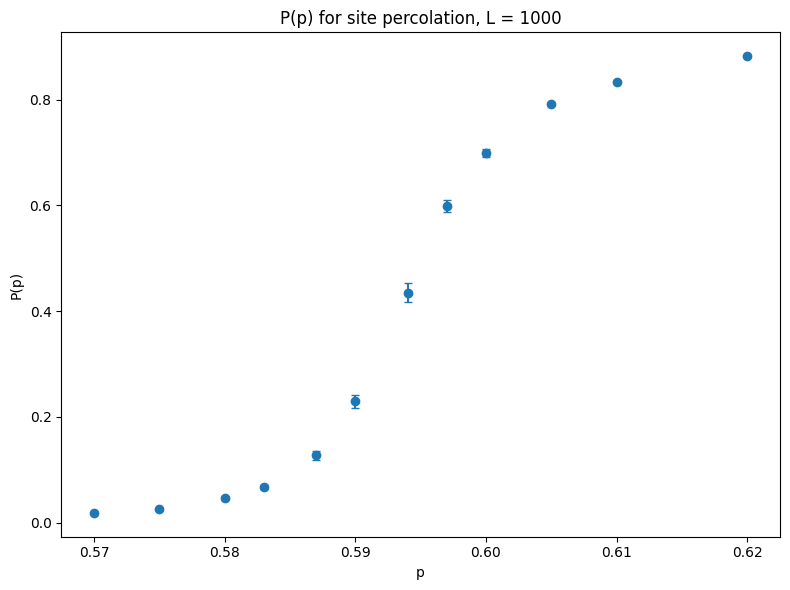

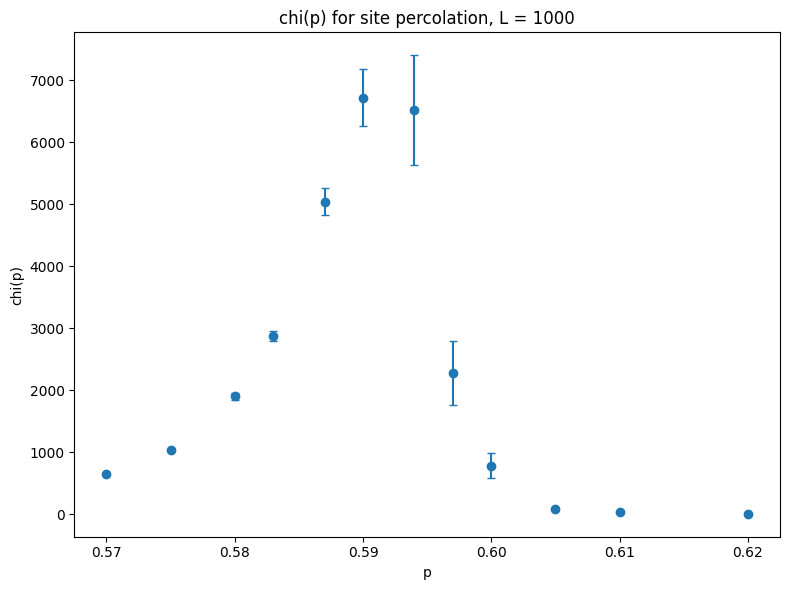

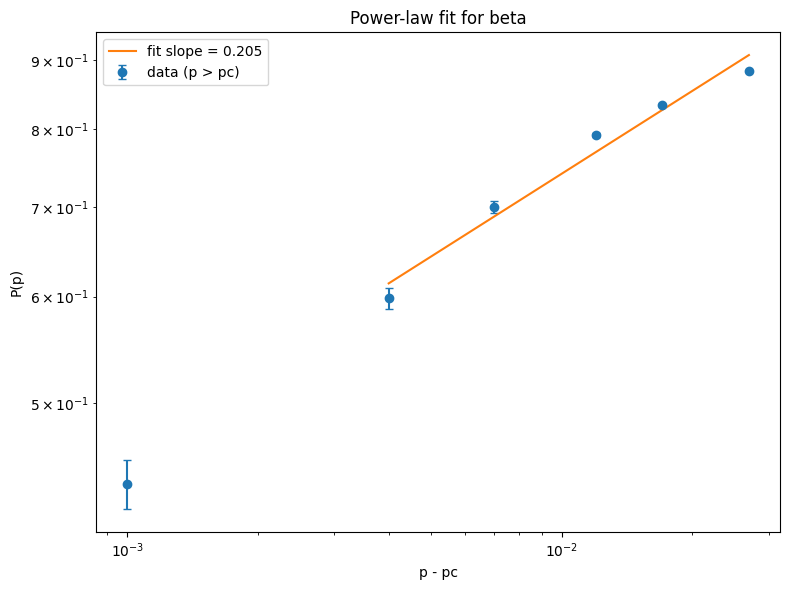

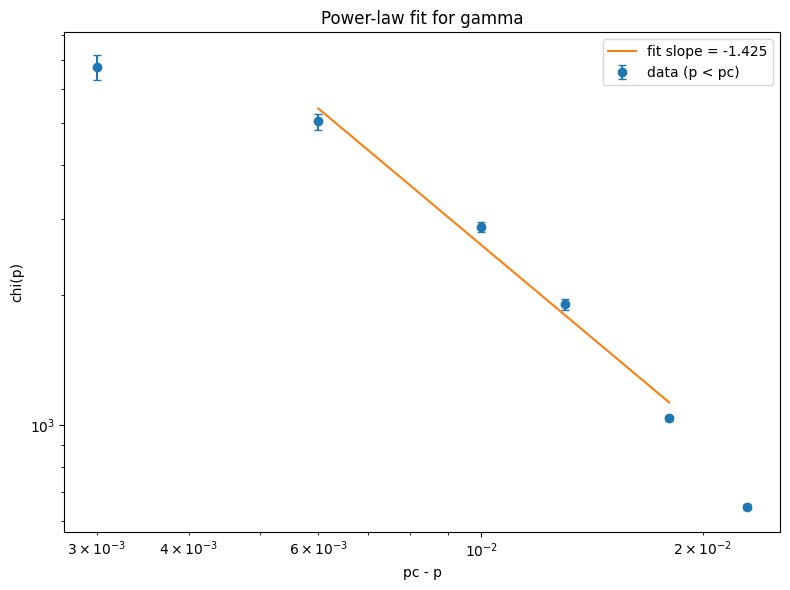

In [ ]:
# Lab 10 - Task 2

import numpy as np;
import random;
import matplotlib.pyplot as plt;


# Percolation generator
def generate(p, grid):
    L = grid.shape[0];
    grid.fill(0);
    labels = np.zeros(L * L, dtype = int);
    lbl = 0;

    for i in range(L):
        for j in range(L):
            if random.random() > p:
                continue;

            topIdx = grid[i, j - 1] if j > 0 else 0;
            leftIdx = grid[i - 1, j] if i > 0 else 0;

            while labels[topIdx] < 0:
                topIdx = -labels[topIdx];
            while labels[leftIdx] < 0:
                leftIdx = -labels[leftIdx];

            if topIdx == 0 and leftIdx == 0:
                lbl += 1;
                trueIdx = lbl;
            elif topIdx == 0:
                trueIdx = leftIdx;
            elif leftIdx == 0:
                trueIdx = topIdx;
            else:
                if topIdx != leftIdx:
                    idxLO = min(topIdx, leftIdx);
                    idxHI = max(topIdx, leftIdx);
                    trueIdx = idxLO;
                    labels[idxLO] += labels[idxHI];
                    labels[idxHI] = -idxLO;
                else:
                    trueIdx = leftIdx;

            grid[i, j] = trueIdx;
            labels[trueIdx] += 1;

    Noccupied = 0;
    sDist = {};

    for idx in range(1, lbl + 1):
        s = labels[idx];
        if s < 0:
            continue;
        Noccupied += s;
        if s not in sDist:
            sDist[s] = 1;
        else:
            sDist[s] += 1;

    sDist = sorted(sDist.items());   # list of cluster size s, number Ns
    return Noccupied, sDist;


# Observables
def compute_P_chi(L, Noccupied, sDist):
    if Noccupied == 0 or len(sDist) == 0:
        return 0.0, 0.0;

    s_max = sDist[-1][0];
    P = s_max / Noccupied; # Order parameter again
    chi = 0.0;  # Susceptibility / mean finite-cluster size up to a constant factor

    for s, Ns in sDist[:-1]:   # exclude largest cluster
        chi += s * s * Ns;
    chi /= (L * L);

    return P, chi;


# Statistics at one p
def run_at_p(L, p, Nsamples):
    grid = np.zeros((L, L), dtype = int);
    P_vals = np.zeros(Nsamples);
    chi_vals = np.zeros(Nsamples);

    for n in range(Nsamples):
        Noccupied, sDist = generate(p, grid);
        P_vals[n], chi_vals[n] = compute_P_chi(L, Noccupied, sDist);

    return {"p": p, "P_mean": np.mean(P_vals), "P_sem": np.std(P_vals, ddof = 1) / np.sqrt(Nsamples), "chi_mean": np.mean(chi_vals),
        "chi_sem": np.std(chi_vals, ddof = 1) / np.sqrt(Nsamples),};


# Log-log fit
def loglog_fit(x, y):
    lx = np.log(x);
    ly = np.log(y);
    slope, intercept = np.polyfit(lx, ly, 1);
    ly_fit = slope * lx + intercept;
    ss_res = np.sum((ly - ly_fit) ** 2);
    ss_tot = np.sum((ly - np.mean(ly)) ** 2);
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan;

    return slope, intercept, r2;


# Main
def main():
    pc = 0.593
    L = 1000
    Nsamples = 60
    p_values = np.array([0.570, 0.575, 0.580, 0.583, 0.587, 0.590, 0.594, 0.597, 0.600, 0.605, 0.610, 0.620]);
    # Final Task 1 estimates
    beta_over_nu_task1 = 0.136870
    gamma_over_nu_task1 = 1.797570
    random.seed(12345)
    np.random.seed(12345)

    # Run simulations
    results = [];
    for p in p_values:
        print(f"Running p = {p:.3f} ...");
        results.append(run_at_p(L, p, Nsamples));

    # Convert to arrays
    p = np.array([r["p"] for r in results], dtype = float);
    P_mean = np.array([r["P_mean"] for r in results], dtype = float);
    P_sem = np.array([r["P_sem"] for r in results], dtype = float);
    chi_mean = np.array([r["chi_mean"] for r in results], dtype = float);
    chi_sem = np.array([r["chi_sem"] for r in results], dtype = float);


    # Fit windows
    beta_fit_mask = (p >= 0.596) & (p <= 0.620);     # beta: supercritical side only, near but not too near pc
    gamma_fit_mask = (p >= 0.575) & (p <= 0.588);  # gamma: subcritical side only, near but not too near pc

    dp_beta = p[beta_fit_mask] - pc;
    P_fit_vals = P_mean[beta_fit_mask];
    dp_gamma = pc - p[gamma_fit_mask];
    chi_fit_vals = chi_mean[gamma_fit_mask];

    slope_beta, intercept_beta, r2_beta = loglog_fit(dp_beta, P_fit_vals);
    slope_gamma_raw, intercept_gamma, r2_gamma = loglog_fit(dp_gamma, chi_fit_vals);
    beta_est = slope_beta;
    gamma_est = -slope_gamma_raw;

    # Estimate nu
    nu_from_beta = beta_est / beta_over_nu_task1;
    nu_from_gamma = gamma_est / gamma_over_nu_task1;
    nu_avg = 0.5 * (nu_from_beta + nu_from_gamma);

    # Averaged results first
    print("\nAveraged results");
    print("-----------------------------------------------------------------------");
    print(f"{'p':>8} {'<P>':>12} {'SEM(P)':>12} {'<chi>':>14} {'SEM(chi)':>14}");
    print("-----------------------------------------------------------------------");
    for i in range(len(p)):
        print(f"{p[i]:8.3f} {P_mean[i]:12.6f} {P_sem[i]:12.6f} {chi_mean[i]:14.6f} {chi_sem[i]:14.6f}");
    print("\nPower-law fits near pc");
    print("-----------------------------------------------------------------------");
    print("beta fit range:  0.596 <= p <= 0.620   [supercritical side only]");
    print("gamma fit range: 0.575 <= p <= 0.588   [subcritical side only]");
    print(f"P(p)   ~ (p-pc)^beta       => beta  = {beta_est:.6f}");
    print(f"chi(p) ~ (pc-p)^(-gamma)   => gamma = {gamma_est:.6f}");
    print(f"R^2 for beta fit  = {r2_beta:.6f}");
    print(f"R^2 for gamma fit = {r2_gamma:.6f}");
    print("\nEstimated nu from Task 1 + Task 2");
    print("-----------------------------------------------------------------------");
    print(f"nu from beta  = {nu_from_beta:.6f}");
    print(f"nu from gamma = {nu_from_gamma:.6f}");
    print(f"Average nu estimate = {nu_avg:.6f}");

    # Save summary data
    #out = np.column_stack([p, P_mean, P_sem, chi_mean, chi_sem]);
    #np.savetxt("task2_results.csv", out, delimiter = ",", header = "p,P_mean,P_sem,chi_mean,chi_sem",comments = "");

    # Plot P(p)
    plt.figure(figsize = (8, 6));
    plt.errorbar(p, P_mean, yerr = P_sem, fmt = 'o', capsize = 3);
    plt.xlabel("p");
    plt.ylabel("P(p)");
    plt.title(f"P(p) for site percolation, L = {L}");
    plt.tight_layout();
    plt.savefig("task2_P_vs_p.png", dpi = 200);

    # Plot chi(p)
    plt.figure(figsize = (8, 6));
    plt.errorbar(p, chi_mean, yerr = chi_sem, fmt = 'o', capsize = 3);
    plt.xlabel("p");
    plt.ylabel("chi(p)");
    plt.title(f"chi(p) for site percolation, L = {L}");
    plt.tight_layout();
    plt.savefig("task2_chi_vs_p.png", dpi = 200);

    # Plot beta fit
    plt.figure(figsize = (8, 6));
    x_beta_all = p[p > pc] - pc;
    y_beta_all = P_mean[p > pc];
    y_beta_err = P_sem[p > pc];
    plt.errorbar(x_beta_all, y_beta_all, yerr = y_beta_err, fmt = 'o', capsize = 3 , label = 'data (p > pc)');
    plt.plot(dp_beta, np.exp(intercept_beta) * dp_beta**slope_beta, label = f'fit slope = {slope_beta:.3f}');
    plt.xscale('log');
    plt.yscale('log');
    plt.xlabel("p - pc");
    plt.ylabel("P(p)");
    plt.title("Power-law fit for beta");
    plt.legend();
    plt.tight_layout();
    plt.savefig("task2_beta_fit.png", dpi = 200);

    # Plot gamma fit
    plt.figure(figsize = (8, 6));
    x_gamma_all = pc - p[p < pc];
    y_gamma_all = chi_mean[p < pc];
    y_gamma_err = chi_sem[p < pc];
    plt.errorbar(x_gamma_all, y_gamma_all, yerr=y_gamma_err, fmt = 'o', capsize = 3, label = 'data (p < pc)');
    plt.plot(dp_gamma, np.exp(intercept_gamma) * dp_gamma**slope_gamma_raw, label = f'fit slope = {slope_gamma_raw:.3f}');
    plt.xscale('log');
    plt.yscale('log');
    plt.xlabel("pc - p");
    plt.ylabel("chi(p)");
    plt.title("Power-law fit for gamma");
    plt.legend();
    plt.tight_layout();
    plt.savefig("task2_gamma_fit.png", dpi = 200);

    plt.show();


if __name__ == "__main__":
    main();


# EOF

